<a href="https://colab.research.google.com/github/MartinDelhaye/Projet-ML-Mobile/blob/dev/notebooks/mnist_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. MNIST Training
## Les imports

In [24]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn

## 1. Transformation des données

Avant de charger les données, on définit les transformations à appliquer
sur chaque image :
- ToTensor() : convertit l'image en tensor PyTorch et divise les pixels
  par 255, passant de [0, 255] à [0, 1]
- Normalize(0.5, 0.5) : centre les valeurs autour de 0 en passant
  de [0, 1] à [-1, 1], ce qui stabilise l'apprentissage

In [25]:
transform = transforms.Compose([
    transforms.ToTensor(),        # convertit l'image en tensor ET divise par 255
    transforms.Normalize((0.5,), (0.5,))  # ramène vers [-1, 1]
])

## 2. Chargement du dataset MNIST

On charge deux versions du dataset :
- train=True : 60 000 images pour entraîner le modèle
- train=False : 10 000 images pour évaluer les performances
  sur des données jamais vues par le modèle


In [26]:
train_dataset = datasets.MNIST(root='./data', train=True,
                                download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False,
                               download=True, transform=transform)

## 3. Création des DataLoaders

Le DataLoader charge les données par petits groupes appelés "batches".
On utilise batch_size=64, ce qui veut dire que le modèle voit 64 images
à la fois avant de mettre à jour ses poids.
- shuffle=True pour le train : on mélange les données à chaque epoch
  pour éviter que le modèle apprenne dans un ordre fixe
- shuffle=False pour le test : l'ordre n'a pas d'importance ici

In [27]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## 4. Vérification visuelle des données

On affiche quelques images du dataset pour vérifier que
le chargement s'est bien passé.

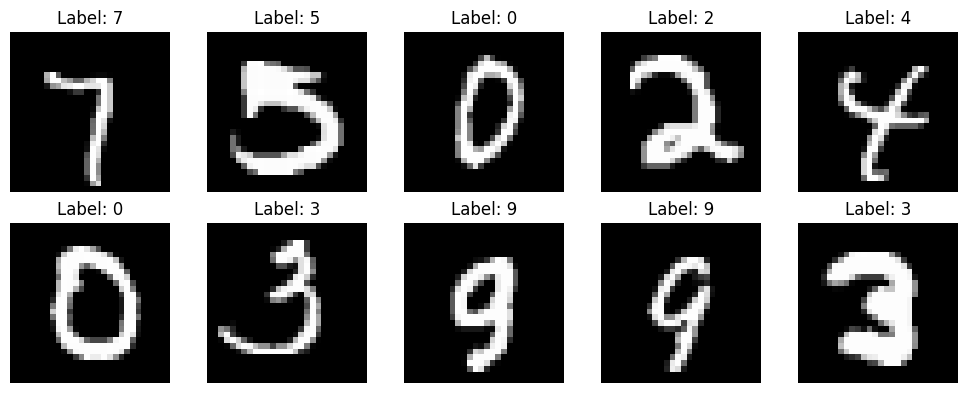

In [28]:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Construction du modèle CNN

Le modèle est composé de deux parties :
- Couches de convolution : détectent les patterns visuels (contours, courbes...)
  en appliquant des filtres qui se déplacent sur l'image
- Couches linéaires : prennent ces patterns et classifient le chiffre (0 à 9)

In [29]:
class MnistCNN(nn.Module):
    def __init__(self):
        super(MnistCNN, self).__init__()

        # Partie convolution
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Partie classification
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = MnistCNN()
print(model)

MnistCNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 6. Fonction de perte et optimiseur

- CrossEntropyLoss : adaptée à la classification, elle mesure
  à quel point le modèle est confiant et correct dans ses prédictions
- Adam : optimiseur qui adapte automatiquement le learning rate
  pendant l'apprentissage, plus efficace que SGD simple

In [30]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 7. Boucle d'entraînement

À chaque epoch, on parcourt tous les batches du dataset d'entraînement.
Pour chaque batch :
1. Forward pass : le modèle fait une prédiction
2. On calcule l'erreur avec CrossEntropyLoss
3. Backward pass : PyTorch calcule les gradients (backpropagation)
4. L'optimiseur met à jour les poids du modèle

In [ ]:
def train(model, train_loader, criterion, optimizer, epochs=5):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for images, labels in train_loader:
            # 1. Remettre les gradients à zéro
            optimizer.zero_grad()

            # 2. Forward pass
            outputs = model(images)

            # 3. Calcul de l'erreur
            loss = criterion(outputs, labels)

            # 4. Backward pass
            loss.backward()

            # 5. Mise à jour des poids
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f'Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}')

train(model, train_loader, criterion, optimizer)

Epoch 1/5 - Loss: 0.1571
Epoch 2/5 - Loss: 0.0442
Epoch 3/5 - Loss: 0.0314
Epoch 4/5 - Loss: 0.0233
Epoch 5/5 - Loss: 0.0173


## 8. Évaluation du modèle

On évalue le modèle sur le dataset de test (10 000 images jamais vues).
On calcule la précision (accuracy) : le pourcentage d'images correctement classifiées.
model.eval() désactive certains comportements spécifiques à l'entraînement
torch.no_grad() désactive le calcul des gradients car on en a pas besoin ici,
ce qui accélère les calculs.

In [32]:
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Précision sur le test set: {accuracy:.2f}%')

evaluate(model, test_loader)

Précision sur le test set: 99.00%


## 9. Sauvegarde du modèle

On sauvegarde les poids du modèle entraîné dans un fichier .pt
pour pouvoir le réutiliser dans l'API sans réentraîner.
- state_dict() : contient uniquement les poids du modèle

In [33]:
torch.save(model.state_dict(), 'mnist_cnn.pt')
print("Modèle sauvegardé !")

Modèle sauvegardé !
